# 02 · Exit-policy study, squeeze_bull arm (report-only)

**Question.** Is squeeze_bull's 48 h time stop — the exit that closed SJ-4250 — doing anything? How far do the bounces
run, would another target do better, does a "flush resumed" exit help, and what does the time stop do for the no-stop
twin?

Frozen rules: [PREREGISTRATION_SQUEEZE_BULL.md](PREREGISTRATION_SQUEEZE_BULL.md). Write-up:
[findings_squeeze_bull.md](findings_squeeze_bull.md). **Report-only: nothing may change before the n = 20 / 30 re-cuts.**
This notebook recomputes every walk on the Binance perpetual 1-minute path and checks it against the saved files.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION_SQUEEZE_BULL.md").exists(), "execute from studies/notebooks/exit_policy_2026_09"
sys.path.insert(0, str(STUDY)); sys.path.insert(0, str(STUDY.parent / "orb_study"))
import sqb_lib as S, sqb_run as RUN
from review_plots import AXIS, INK2, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 30)
RES = S.RESULTS
F0, PRE, REP, DRIFT = (json.loads((RES / f).read_text()) for f in
                       ("freeze_F0.json", "preconditions.json", "report.json", "exploratory_regime_drift.json"))
changed = [f for f, h in F0["files"].items() if S.sha256(S.ROOT / f) != h]
print("F0", F0["created_utc"], "| frozen files unchanged:", not changed, "| report", REP["created_utc"])
fires = S.load_fires()
walks, report = RUN.compute_report(S.load_path(), fires, S.load_hourly_flush_bars()["flush_bar_ts"])
saved = pd.read_csv(RES / "walks.csv.gz")
cols = ["bar_ts", "arm", "kind", "exit_s"]
print("walks identical to the saved run:",
      walks[cols].astype(str).equals(saved[cols].astype(str)) and np.allclose(walks["net_R"], saved["net_R"], rtol=0, atol=1e-9))
pd.DataFrame({k: {"pass": v["pass"]} for k, v in PRE.items() if isinstance(v, dict) and "pass" in v}).T

F0 2026-09-15T13:26:44+00:00 | frozen files unchanged: True | report 2026-09-15T13:26:49+00:00


walks identical to the saved run: True


,pass
Q1,True
Q2,True
Q3,True
Q4,True
Q5,True
Q6,True


## 1. Every arm, and the paired differences

Net R per trade (R = 2 % of entry, 7 bp, actual funding) on all 122 fires. Incumbent arms are compared with the shipped
S0, twin arms with the shipped twin N0, and the twin with the incumbent. Intervals: 30-day block bootstrap of entry days.

,mean_net_R,mean_R_no_funding,mean_funding_R,win_rate,median_hours_held,worst_R,exit_mix
S0,0.259233,0.27079,-0.011557,0.565574,21.0,-1.066161,"{'target': 49, 'stop': 43, 'time': 30}"
S_T12,0.12281,0.12723,-0.004421,0.565574,12.0,-1.04008,"{'time': 92, 'stop': 19, 'target': 11}"
S_T24,0.227448,0.235263,-0.007815,0.598361,21.0,-1.051916,"{'time': 56, 'target': 33, 'stop': 33}"
S_T72,0.257015,0.270828,-0.013813,0.54918,21.0,-1.089893,"{'target': 55, 'stop': 49, 'time': 18}"
S_NOTIME,0.259314,0.276475,-0.017161,0.52459,21.0,-1.163627,"{'target': 64, 'stop': 58}"
S_TGT4,0.250413,0.264956,-0.014543,0.52459,32.416667,-1.066161,"{'stop': 46, 'time': 45, 'target': 31}"
S_TGT5,0.30974,0.325347,-0.015606,0.52459,40.491667,-1.066161,"{'time': 54, 'stop': 46, 'target': 22}"
S_TGT6,0.266524,0.28452,-0.017995,0.516393,48.0,-1.066161,"{'time': 63, 'stop': 47, 'target': 12}"
S_NOTGT,0.261313,0.28166,-0.020347,0.516393,48.0,-1.066161,"{'time': 75, 'stop': 47}"
C_REFLUSH,0.238459,0.250761,-0.012303,0.516393,19.375,-1.091486,"{'target': 54, 'stop': 43, 'event': 25}"


,mean_d,ci95_lo,ci95_hi,first_half,second_half,fires_changed
S_T12_minus_S0,-0.136,-0.265,-0.008,-0.091,-0.227,92.0
S_T24_minus_S0,-0.032,-0.098,0.037,-0.030,-0.034,56.0
S_T72_minus_S0,-0.002,-0.070,0.061,-0.001,-0.005,30.0
S_NOTIME_minus_S0,0.000,-0.121,0.111,0.064,-0.126,30.0
S_TGT4_minus_S0,-0.009,-0.089,0.062,0.013,-0.053,49.0
S_TGT5_minus_S0,0.051,-0.041,0.136,0.069,0.015,49.0
S_TGT6_minus_S0,0.007,-0.109,0.114,0.004,0.014,49.0
S_NOTGT_minus_S0,0.002,-0.135,0.151,-0.015,0.036,49.0
C_REFLUSH_minus_S0,-0.021,-0.126,0.074,0.057,-0.174,41.0
N_NOTIME_minus_N0,0.040,-0.491,0.460,0.265,-0.403,67.0


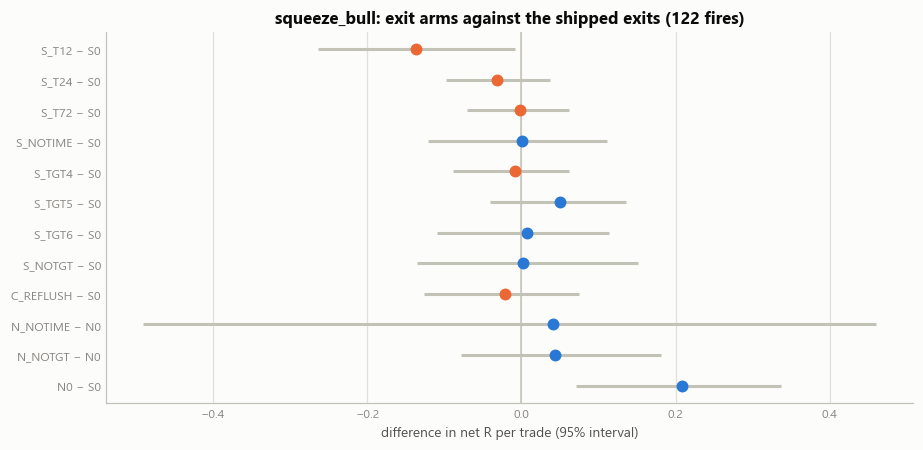

In [2]:
display(pd.DataFrame(REP["by_arm"]).T[["mean_net_R", "mean_R_no_funding", "mean_funding_R", "win_rate",
                                       "median_hours_held", "worst_R", "exit_mix"]].round(3))
P = pd.DataFrame({k: {"mean_d": v["mean_d"], "ci95_lo": v["ci95"][0], "ci95_hi": v["ci95"][1], "first_half": v["first_half"],
                      "second_half": v["second_half"], "fires_changed": v["fires_changed"]} for k, v in REP["paired"].items()}).T
display(P.round(3))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
keys = list(REP["paired"])
y = np.arange(len(keys))[::-1]
for yi, k in zip(y, keys):
    v = REP["paired"][k]
    ax.hlines(yi, v["ci95"][0], v["ci95"][1], color=AXIS, linewidth=2)
    ax.scatter([v["mean_d"]], [yi], s=46, zorder=3, color=SERIES[0] if v["mean_d"] >= 0 else SERIES[1])
ax.axvline(0, color=AXIS, linewidth=1)
ax.set_yticks(y); ax.set_yticklabels([k.replace("_minus_", " − ") for k in keys], fontsize=8)
style(ax, grid_axis="x"); ax.set_xlabel("difference in net R per trade (95% interval)")
ax.set_title("squeeze_bull: exit arms against the shipped exits (122 fires)")
plt.tight_layout(); plt.show()

## 2. The time stop, trade by trade

The 30 trades the shipped exit closes on its 48 h time stop, held to their stop or target instead.

In [3]:
pd.Series(REP["s0_time_stopped_held_without_time_stop"]).to_frame("value")

,value
fires,30
S0_mean_net_R,0.171287
S_NOTIME_mean_net_R,0.171618
S_NOTIME_exit_mix,"{'target': 15, 'stop': 15}"
median_hours_to_resolution,79.341667


## 3. How far the bounces run, against the bull regime's own drift

Best and worst price after entry, the share of fires reaching each target before −2 %, and the average move after entry
compared with every hour of the same causal bull regime (an exploratory control added after the report).

,mean,median,p25,p75
mfe_pct_48h,3.29,2.67,1.64,4.41
mae_pct_48h,-2.05,-1.24,-2.79,-0.62
hours_to_mfe_48h,26.75,27.66,16.23,40.31
mfe_pct_7d,6.46,5.36,2.95,8.49
mae_pct_7d,-4.02,-2.89,-5.20,-1.25
hours_to_mfe_7d,92.60,95.31,42.17,144.65


,share of fires
reach_3pct_before_stop_7d,0.525
reach_4pct_before_stop_7d,0.426
reach_5pct_before_stop_7d,0.361
reach_6pct_before_stop_7d,0.295


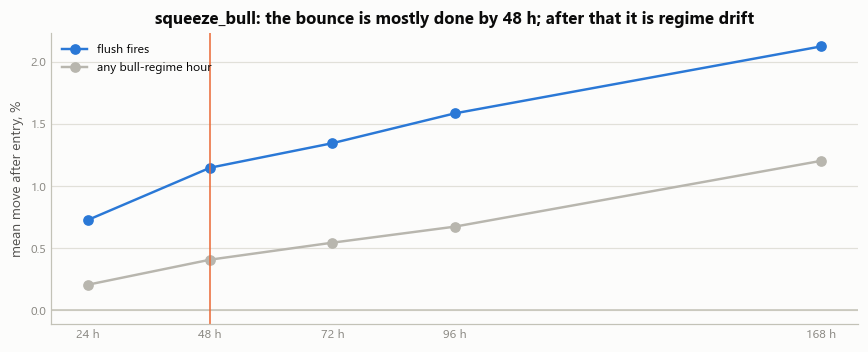

In [4]:
display(pd.DataFrame({k: v for k, v in REP["excursions"].items() if isinstance(v, dict)}).T.round(2))
display(pd.Series({k: v for k, v in REP["excursions"].items() if not isinstance(v, dict)}).round(3).to_frame("share of fires"))
h = [int(x) for x in DRIFT["by_horizon_h"]]
fires_m = [DRIFT["by_horizon_h"][str(x)]["fires_mean_pct"] for x in h]
bull_m = [DRIFT["by_horizon_h"][str(x)]["mean_pct"] for x in h]
fig, ax = plt.subplots(figsize=(8, 3.3))
ax.plot(h, fires_m, marker="o", color=SERIES[0], label="flush fires")
ax.plot(h, bull_m, marker="o", color=NEUTRAL, label="any bull-regime hour")
ax.axvline(48, color=SERIES[1], linewidth=1)
ax.set_xticks(h); ax.set_xticklabels([f"{x} h" for x in h], fontsize=8)
style(ax); zero_line(ax); ax.set_ylabel("mean move after entry, %"); ax.legend(loc="upper left")
ax.set_title("squeeze_bull: the bounce is mostly done by 48 h; after that it is regime drift")
plt.tight_layout(); plt.show()

## 4. The bot's own sequence

One position at a time, $10,000, 1 % risk per trade; drawdown against the fixed capital.

In [5]:
pd.DataFrame(REP["single_open_sequence"]).T.round(1)

,trades,total_return_pct,max_drawdown_pct
S0,118.0,31.3,4.6
S_T12,122.0,15.0,3.8
S_T24,122.0,27.7,5.4
S_T72,113.0,33.1,4.5
S_NOTIME,111.0,30.8,6.6
S_TGT4,111.0,34.8,5.8
S_TGT5,108.0,40.3,5.8
S_TGT6,104.0,35.4,5.8
S_NOTGT,102.0,34.2,5.8
C_REFLUSH,122.0,29.1,6.2


## Conclusion (report-only)

- The incumbent's 48 h time stop is a coin flip on the trades it closes: held, they split 15 targets and 15 stops for the
  same average. Removing it changes nothing on average and adds drawdown; 12 h is clearly worse.
- For the no-stop twin the time stop is the risk control: without it, 15 trades end at −10 % and drawdown more than doubles.
- Wider targets, no target and "flush resumed" are within noise of the shipped exit.
- The twin beats the incumbent by +0.21 R per trade on this clean paired test, but almost all of it is before mid-2024. The
  n = 20 / 30 live re-cut stays the decision point.